# Cluster analysis(for zeta order)

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))
from config import paths

traj = paths.get_trajectory_path
figto = paths.get_figure_path
data = paths.get_data_path

In [7]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150
matplotlib.rcParams['savefig.dpi'] = 300
matplotlib.rcParams['font.size'] = 12
%matplotlib inline
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy.spatial import ConvexHull

import os
import numpy as np
import matplotlib.pyplot as plt
import MDAnalysis as mda
from collections import defaultdict

from tools.custom_hbond_analysis import HydrogenBondAnalysis as HBA
from tools.zeta_order_parameter import ZetaOrderParameter as ZOP
from tools.zeta_cluster_analysis import ZetaClusterAnalysis  as ZCA

os.makedirs(figto("cluster_plots"), exist_ok=True) 

In [3]:
u = mda.Universe(
    traj("tip4p-ice-225K.data"),
    traj("dump_225_test.lammpstrj"),
    format="LAMMPSDUMP",
    dt=0.2,
)

hba = HBA(
    universe=u,
    donors_sel="type 1",
    hydrogens_sel="type 2",
    acceptors_sel="type 1",
    d_a_cutoff=3.5,
    h_d_a_angle_cutoff=30.0,
    update_selections=False,
)
hba.run(verbose=True)

zop = ZOP(hba=hba, central_sel="type 1", shell_cutoff=6.0)
zop.run(verbose=True)

zca = ZCA(
    zop=zop,
    eps=3.5,            # Å – first O-O shell for ice ≈ 2.75 Å, use 3.5 for some slack
    min_samples=4,      # minimum cluster size (central molecule + 3 neighbours)
    zeta_threshold=0.4,
    min_track_overlap=0.3,
    min_track_lifetime=2,
    cluster_classes=(1, -1),
)
zca.run(verbose=True)

100%|██████████| 2501/2501 [02:17<00:00, 18.24it/s]


In [4]:
# Convenience aliases
central_indices = zca.results.central_indices   # OW atom indices
times_ps        = zca.results.times             # shape (n_frames,)
n_frames        = len(zca.frames)
dt              = u.trajectory.dt               # ps per frame

In [5]:
# ============================================================================
# Helper: thin spatial slab selector
# ============================================================================

def get_slab_mask(positions, box_lengths, axis=2, centre=None, width=5.0):
    """Return boolean mask for atoms within a slab of given width (Å).

    Parameters
    ----------
    positions   : np.ndarray, shape (N, 3)
    box_lengths : array-like, shape (3,) – box lengths [lx, ly, lz]
    axis        : 0=x, 1=y, 2=z
    centre      : float or None – slab midpoint; None → box centre
    width       : float – full slab thickness in Å
    """
    L   = box_lengths[axis]
    mid = L / 2.0 if centre is None else centre
    z   = positions[:, axis]
    # Minimum-image along the slab axis
    dz  = z - mid
    dz -= L * np.round(dz / L)
    return np.abs(dz) <= width / 2.0

TypeError: PathConfig.get_figure_path() missing 1 required positional argument: 'filename'

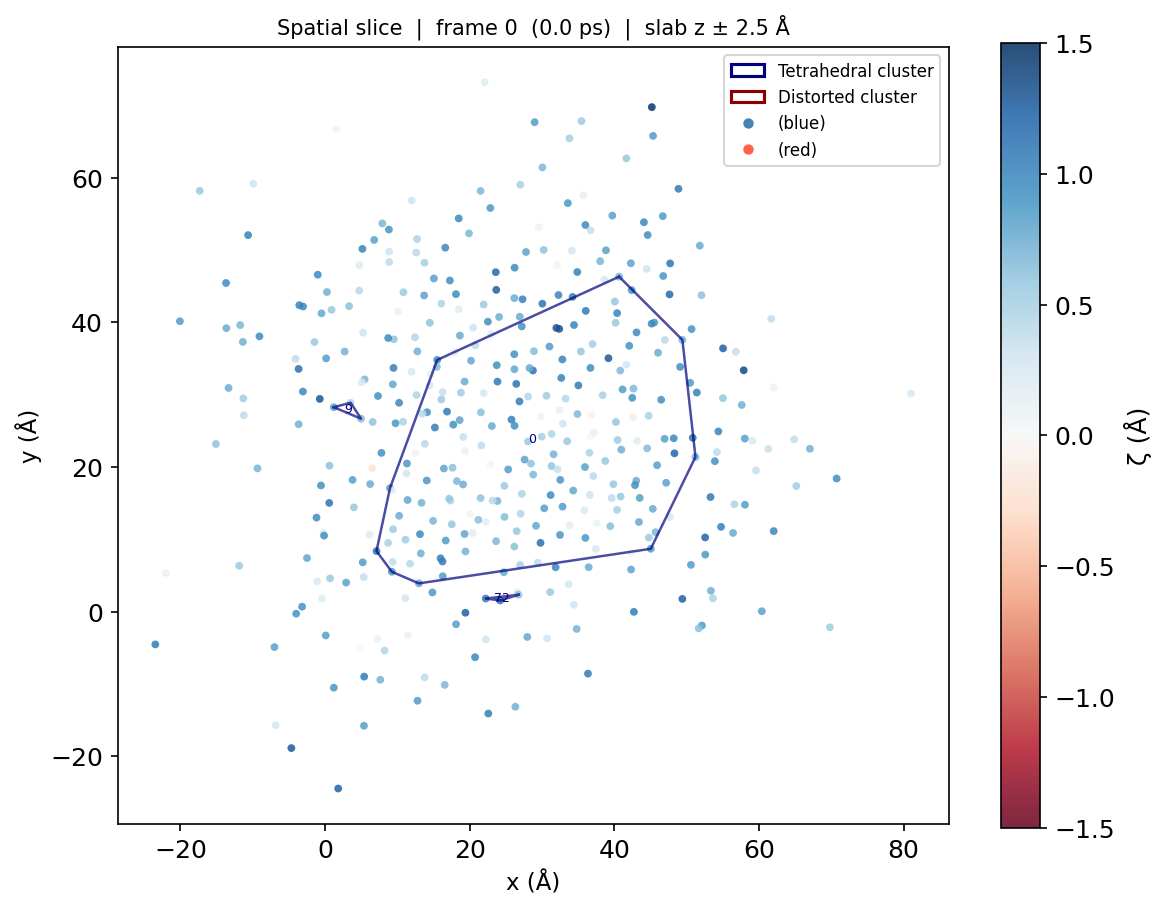

In [9]:

# ============================================================================
# 1.  Spatial slice snapshot coloured by ζ, cluster convex-hull overlaid
# ============================================================================

def plot_spatial_slice(frame_idx, axis=2, width=5.0, ax=None, show=True):
    """
    Parameters
    ----------
    frame_idx : index into zca.frames (not the trajectory frame number)
    axis      : 0/1/2 → x/y/z as slab normal
    width     : slab thickness (Å)
    """
    frame  = zca.frames[frame_idx]
    u.trajectory[frame]
    box    = u.trajectory.ts.dimensions
    box_L  = box[:3]

    # Positions and ζ for all central (OW) atoms
    positions = zca._central_ag.positions.copy()   # (N, 3)
    zop_row   = zop._frame_to_row[frame]
    zeta_vals = zop.results.zeta[zop_row].copy()

    # Structural labels at this frame
    labels    = zca.results.frame_labels[frame_idx]
    cluster_ids = zca.results.frame_cluster_ids[frame_idx]

    # Slab mask
    slab = get_slab_mask(positions, box_L, axis=axis, width=width)
    idx_in_slab   = np.where(slab)[0]

    if len(idx_in_slab) == 0:
        print(f"No atoms in slab at frame {frame}.")
        return

    ax_x, ax_y  = [i for i in range(3) if i != axis]
    pos_slab    = positions[idx_in_slab]
    zeta_slab   = zeta_vals[idx_in_slab]
    gid_slab    = cluster_ids[idx_in_slab]
    label_slab  = labels[idx_in_slab]

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 7))
        created_fig = True
    else:
        created_fig = False

    # ---- Scatter coloured by ζ -------------------------------------------
    norm = mcolors.TwoSlopeNorm(vmin=-1.5, vcenter=0.0, vmax=1.5)
    sc   = ax.scatter(
        pos_slab[:, ax_x], pos_slab[:, ax_y],
        c=zeta_slab, cmap="RdBu", norm=norm,
        s=14, linewidths=0, alpha=0.85, zorder=2,
    )

    # ---- Convex hull outlines for each tracked cluster -------------------
    unique_gids = np.unique(gid_slab[gid_slab >= 0])
    hull_colors = {1: "navy", -1: "darkred"}

    for gid in unique_gids:
        gid_mask  = gid_slab == gid
        pts       = pos_slab[gid_mask][:, [ax_x, ax_y]]
        if len(pts) < 3:
            continue
        cls       = label_slab[gid_mask][0]
        try:
            hull  = ConvexHull(pts)
            verts = np.append(hull.vertices, hull.vertices[0])
            ax.plot(pts[verts, 0], pts[verts, 1],
                    color=hull_colors.get(cls, "grey"),
                    lw=1.2, alpha=0.7, zorder=3)
            # Annotate with global cluster ID
            cx, cy = pts.mean(axis=0)
            ax.text(cx, cy, str(gid), fontsize=6,
                    ha="center", va="center",
                    color=hull_colors.get(cls, "grey"), zorder=4)
        except Exception:
            pass

    plt.colorbar(sc, ax=ax, label="ζ (Å)", shrink=0.8)

    axis_labels = ["x", "y", "z"]
    ax.set_xlabel(f"{axis_labels[ax_x]} (Å)", fontsize=11)
    ax.set_ylabel(f"{axis_labels[ax_y]} (Å)", fontsize=11)
    ax.set_title(
        f"Spatial slice  |  frame {frame}  ({frame * dt:.1f} ps)  "
        f"|  slab {axis_labels[axis]} ± {width/2:.1f} Å",
        fontsize=10,
    )
    legend_handles = [
        Patch(edgecolor="navy",    facecolor="none", lw=1.5, label="Tetrahedral cluster"),
        Patch(edgecolor="darkred", facecolor="none", lw=1.5, label="Distorted cluster"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="steelblue",
               markersize=6, label="(blue)"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="tomato",
               markersize=6, label="(red)"),
    ]
    ax.legend(handles=legend_handles, fontsize=8, loc="upper right")
    ax.set_aspect("equal")

    if created_fig and show:
        plt.tight_layout()
        plt.savefig(figto() / f"cluster_plots/spatial_slice_frame{frame_idx:04d}.png")
        plt.close()


# Plot snapshot at the first, middle, and last frames
for fi in [0, n_frames // 2, n_frames - 1]:
    plot_spatial_slice(fi, axis=2, width=5.0, show=True)
    print(figto() / f"Slice written: cluster_plots/spatial_slice_frame{fi:04d}.png")